## Pricing & Profit Optimization Pipeline

Are discounts killing profit?
Does giving discount help or hurt profit?

## Load Data

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv
/kaggle/input/datasets/mamtapathak/superstore-datasets/sample superstore.xls


In [2]:
import pandas as pd 

df = pd.read_csv('/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv',encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Feature Engineering 

In [3]:
# create profit margin 
# If = 0.2 → you keep 20% profit
# If = negative → you’re losing money


df["Profit_Margin"] = df["Profit"] / df["Sales"]

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit_Margin
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125


In [5]:
# discount vs profit 
#For each discount level → what’s the average profit?
 

df.groupby("Discount")["Profit"].mean().reset_index()

,Discount,Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212


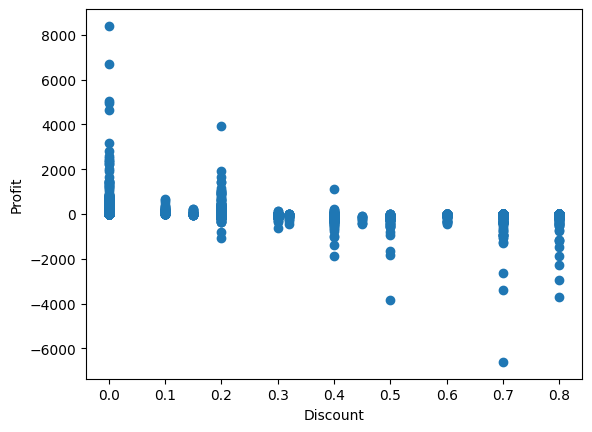

In [6]:
# plot 


import matplotlib.pyplot as plt

plt.scatter(df["Discount"], df["Profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [7]:
# group discount 

df["Discount_Level"] = pd.cut(
    df["Discount"],
    bins=[0, 0.1, 0.3, 0.5, 1],
    labels=["Low", "Medium", "High", "Very High"]
)

In [8]:
# observed=False - panda new setting 

df.groupby("Discount_Level", observed=False)["Profit"].mean()


Discount_Level
Low           96.055074
Medium        20.677597
High        -156.282991
Very High    -89.438144
Name: Profit, dtype: float64

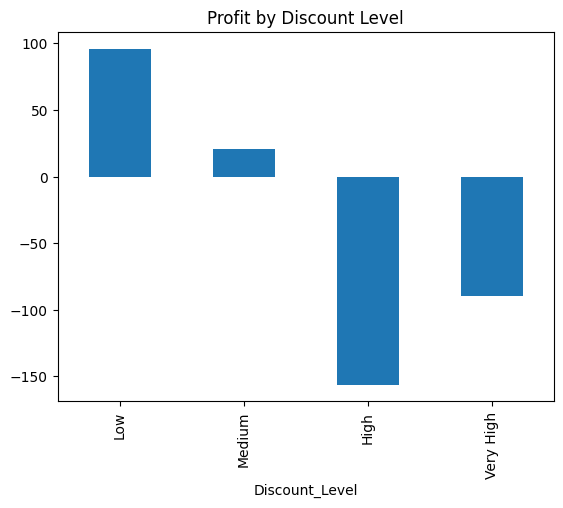

In [9]:
# plot 


df.groupby("Discount_Level", observed=False)["Profit"].mean().plot(kind="bar")
plt.title("Profit by Discount Level")
plt.show()

## Insights
*  Low discounts generate the highest profit, showing strong margins when pricing is controlled.
* As discount levels increase, profit drops sharply and becomes negative at high and very high discounts.
* Medium discounts already reduce profitability compared to low discounts.
* Heavy discounting is not translating into sufficient profit gains.

## Conclusion

Profitability is strongly affected by discount strategy. While discounts may help increase sales volume, excessive discounting significantly reduces or destroys profit. The business is currently more efficient at low discount levels and becomes unprofitable when discounts are too aggressive.

## Recommendations
* Limit discounts to low or controlled ranges (0–10%).
* Avoid high and very high discount strategies as they lead to losses.
* Focus on improving value-based pricing instead of relying on discounts.
* Analyze products that require high discounts and review their pricing or cost structure.
* Shift marketing strategy toward profitability rather than just sales volume.
